In [7]:
import pandas as pd

In [8]:
import numpy as np

In [9]:
import matplotlib.pyplot as plt

In [10]:
from sklearn.decomposition import TruncatedSVD

In [14]:
df = pd.read_csv(r"C:\Users\Muaadh moulana\Jupyter Notebook\Video_Game_Sales_Predictor\data\external\5. Feature Selection\Feature Selection(Frequency).csv")

In [15]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Publisher Freq,Developer Freq,Console Freq,Genre Freq,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,0.088207,0.047945,0.562657,1.000000,2010,0.313330,0.484506,0.048697,0.153468,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,0.088207,0.047945,0.378864,1.000000,2010,0.312532,0.500774,0.030944,0.155750,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,0.088207,0.047945,0.887218,1.000000,2000,0.520743,0.339938,0.029102,0.110217,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,0.088207,0.047945,0.543442,1.000000,2010,0.570888,0.335854,0.003781,0.089477,0,High,2
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,1.000000,0.125571,0.378864,0.522903,2010,0.409543,0.400928,0.027170,0.161696,1,High,2


In [23]:
df.dtypes # check data types

Game Title               object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
                         ...   
JP Share                float64
Other Share             float64
Is Recent                 int64
Game Quality             object
Game Quality Encoded      int64
Length: 133, dtype: object

In [24]:
# 1) Build numeric matrix (drop target), clean, and make floats
X = df.drop(columns=["Sales"]).select_dtypes(include=["number", "bool"]).copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.astype(float)

In [25]:
# 2) Find K to hit ~90% variance
max_k = min(50, X.shape[1] - 1) if X.shape[1] > 1 else 1
svd_probe = TruncatedSVD(n_components=max_k, random_state=42)
svd_probe.fit(X)
cumvar = svd_probe.explained_variance_ratio_.cumsum()

# Auto-pick K
K = int(np.searchsorted(cumvar, 0.90) + 1) if X.shape[1] > 1 else 1
K = max(2, min(K, max_k))
print("Chosen components K =", K, "| Cumulative variance ≈", round(cumvar[K-1], 4))

Chosen components K = 2 | Cumulative variance ≈ 0.9581


In [27]:
# 3) Final SVD transform
svd = TruncatedSVD(n_components=K, random_state=42)
Z = svd.fit_transform(X)
comp_cols = [f"SVD_{i+1}" for i in range(K)]

In [28]:
# 4) OVERWRITE df with reduced components + Sales
df = pd.concat(
    [df[["Sales"]].reset_index(drop=True),
     pd.DataFrame(Z, columns=comp_cols)],
    axis=1
)

print("AFTER  (rows, cols):", df.shape)
display(df.head())

AFTER  (rows, cols): (17567, 3)


,Sales,SVD_1,SVD_2
0,1.000000,2844.692241,1.314958
1,0.953740,2845.400196,0.585634
2,0.794291,2829.842199,1.995664
3,0.780512,2844.692198,1.308442
4,0.742126,2846.108077,-0.145832


In [29]:
df.head()

# SVD_1 - a weighted mix of many original features (genre, console, publisher, critic score, etc.) 
        # chosen to capture the largest possible variance

#SVD_2 - another mix of features, capturing the second-most variance

,Sales,SVD_1,SVD_2
0,1.000000,2844.692241,1.314958
1,0.953740,2845.400196,0.585634
2,0.794291,2829.842199,1.995664
3,0.780512,2844.692198,1.308442
4,0.742126,2846.108077,-0.145832


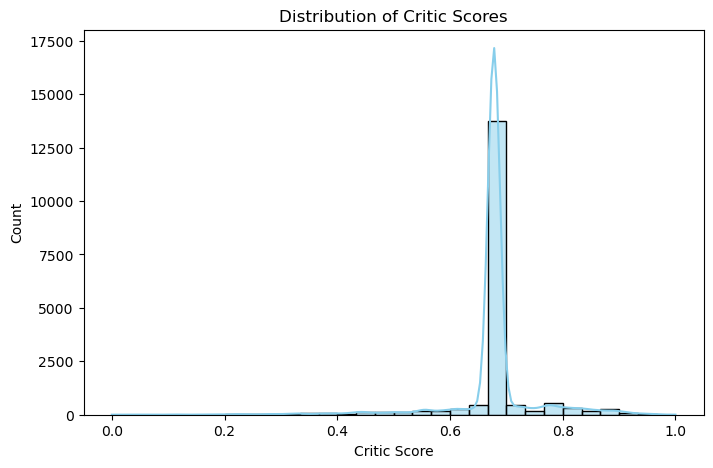

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Critic Score"].dropna(), bins=30, kde=True, color="skyblue")
plt.title("Distribution of Critic Scores")
plt.xlabel("Critic Score")
plt.ylabel("Count")
plt.show()


In [17]:
df.to_csv(r"C:\Users\Muaadh moulana\Jupyter Notebook\Video_Game_Sales_Predictor\data\external\Dimensionality Reduction.csv", index=False)

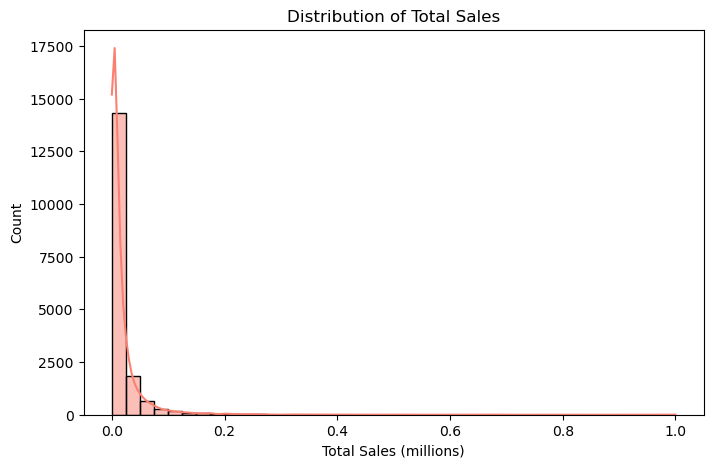

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"].dropna(), bins=40, kde=True, color="salmon")
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales (millions)")
plt.ylabel("Count")
plt.show()


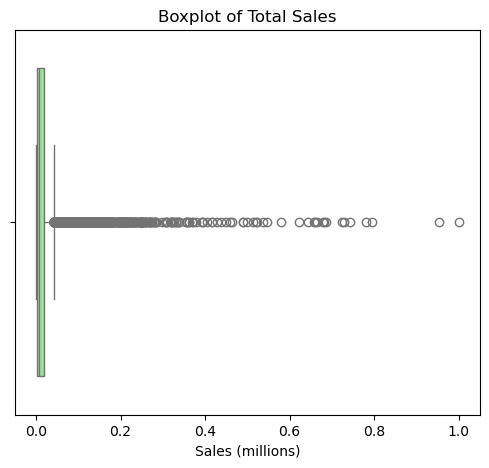

In [20]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df["Sales"], color="lightgreen")
plt.title("Boxplot of Total Sales")
plt.xlabel("Sales (millions)")
plt.show()


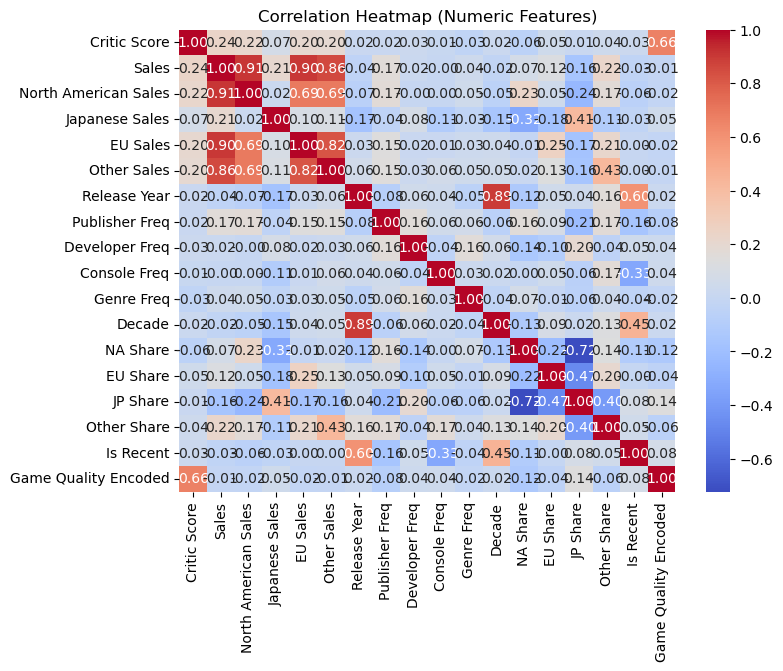

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


C:\Users\Muaadh moulana\AppData\Local\Temp\ipykernel_9764\3249140683.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x="Release Year", y="Sales", data=df, estimator="mean", ci=None, color="purple")


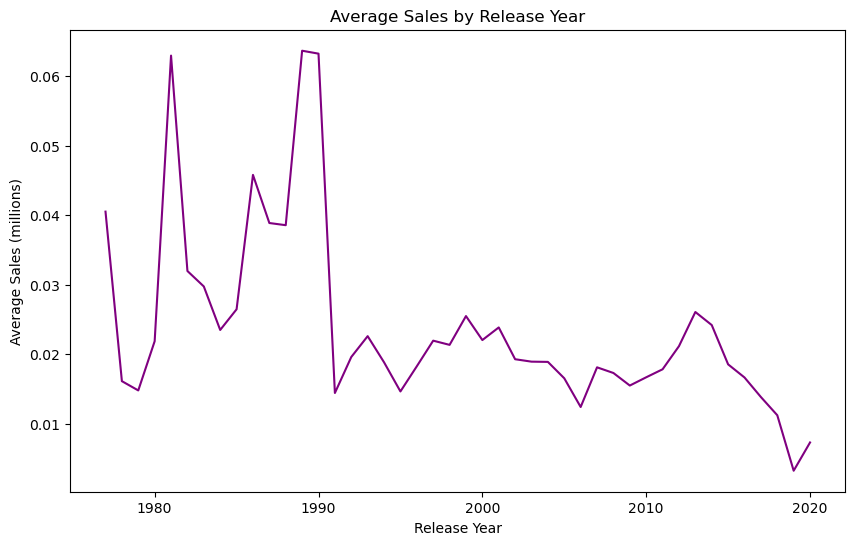

In [24]:
plt.figure(figsize=(10,6))
sns.lineplot(x="Release Year", y="Sales", data=df, estimator="mean", ci=None, color="purple")
plt.title("Average Sales by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Sales (millions)")
plt.show()
